In [ ]:
#Ячейка 1. Импорты

!pip install onnxruntime
!pip install tensorflow
!pip install gdown
import gdown
from zipfile import ZipFile
from google.colab import files
import cv2
import numpy as np
import json
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 88.8 MB/s eta 0:00:00


In [ ]:
#Ячейка 2. Скачивание датасета
file_id = "1_qnuROoWaL3rRxd19Z0MJWEgfVwU0QsN"
url = f"https://drive.google.com/uc?id={file_id}"
output = "mydataset2.zip"

gdown.download(url, output, quiet=False)

with ZipFile("mydataset2.zip", 'r') as zip_ref:
    zip_ref.extractall("mydataset2")

Downloading...
From (original): https://drive.google.com/uc?id=1_qnuROoWaL3rRxd19Z0MJWEgfVwU0QsN
From (redirected): https://drive.google.com/uc?id=1_qnuROoWaL3rRxd19Z0MJWEgfVwU0QsN&confirm=t&uuid=390fee53-e898-4165-8264-dac47057fb52
To: /content/mydataset2.zip
100%|██████████| 4.05G/4.05G [00:24<00:00, 162MB/s]


In [ ]:
print(os.listdir("mydataset2"))
#print(os.listdir("mydataset2/mydataset2"))

['SPECS', 'JSON']


#CNN с нуля

In [ ]:
#ACTUAL
import os
import json
import random

SPEC_DIR = "mydataset2/SPECS"
JSON_DIR = "mydataset2/JSON"

samples = []

for f in os.listdir(SPEC_DIR):

    if not f.endswith(".npy"):
        continue

    base = f[:-4]

    json_path = os.path.join(JSON_DIR, base + ".json")

    if not os.path.exists(json_path):
        continue

    samples.append(base)

random.shuffle(samples)

split = int(len(samples) * 0.8)

train_samples = samples[:split]
val_samples = samples[split:]

print(len(train_samples), len(val_samples))

23208 5803


In [ ]:
#ACTUAL
import tensorflow as tf
import numpy as np

class SpectrogramGenerator(tf.keras.utils.Sequence):

    def __init__(self, samples, batch_size=32):

        self.samples = samples
        self.batch_size = batch_size

    def __len__(self):

        return int(np.ceil(len(self.samples)/self.batch_size))

    def __getitem__(self, idx):

        batch = self.samples[
            idx*self.batch_size:(idx+1)*self.batch_size
        ]

        X = []
        y = []

        for base in batch:

            spec = np.load(
                os.path.join(SPEC_DIR, base+".npy")
            ).astype(np.float32)

            if spec.shape[2] > 128:
                spec = spec[:, :, :128]
            else:
                pad = 128-spec.shape[2]
                spec = np.pad(
                    spec,
                    ((0,0),(0,0),(0,pad))
                )

            spec = np.transpose(spec,(1,2,0))

            with open(os.path.join(JSON_DIR,base+".json")) as f:

                data = json.load(f)

            detected = float(data["detected"])

            if detected:

                angle = data["angle"]

                sin = np.sin(np.deg2rad(angle))
                cos = np.cos(np.deg2rad(angle))

            else:

                sin = 0.
                cos = 0.

            X.append(spec)

            y.append([
                detected,
                sin,
                cos
            ])

        return np.array(X,dtype=np.float32),\
               np.array(y,dtype=np.float32)

In [ ]:
#ACTUAL
train_gen = SpectrogramGenerator(
    train_samples,
    batch_size=32
)

val_gen = SpectrogramGenerator(
    val_samples,
    batch_size=32
)

In [ ]:
#ACTUAL
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,3,activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(3)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#ACTUAL
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


726/726 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 0.1875 - val_loss: 0.0978
Epoch 2/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.0901 - val_loss: 0.0889
Epoch 3/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0762 - val_loss: 0.0722
Epoch 4/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0648 - val_loss: 0.0595
Epoch 5/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 0.0530 - val_loss: 0.0466
Epoch 6/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0409 - val_loss: 0.0344
Epoch 7/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0318 - val_loss: 0.0317
Epoch 8/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0261 - val_loss: 0.0243
Epoch 9/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0225 - val_loss: 0.0206
Epoch 10/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0199 - val_loss: 0.0180
Epoch 11/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0182 - val_loss: 0.0163
Epoch 12/25
726/726 ━━━━━━━━━━━━━━━━━━━━ 

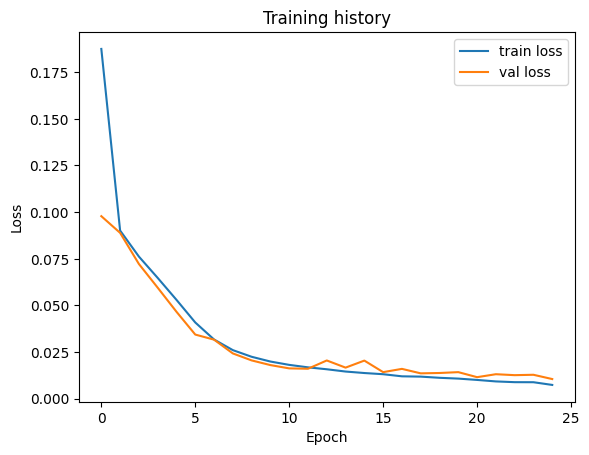

In [ ]:
#ACTUAL
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training history')
plt.show()

In [ ]:
#ACTUAL Ячейка. Экспорт
model.save("model.keras")
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

from google.colab import files
files.download("model.tflite")

Saved artifact at '/tmp/tmp2tzai86v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_17')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132649803324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803324048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803325392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803323856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803323088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803323280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803322704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132649803322896: TensorSpec(shape=(), dtype=tf.resource, name=None)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>